## Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the Dataset

In [6]:
import pandas as pd

users = pd.read_csv("users.csv")
photos = pd.read_csv("photos.csv")
likes = pd.read_csv("likes.csv")
comments = pd.read_csv("comments.csv")
tags = pd.read_csv("tags.csv")
photo_tags = pd.read_csv("photo_tags.csv")
follows = pd.read_csv("follows.csv")

## 3. Exploring the Dataset

In [9]:
users.head()

,id,name,created time,private/public,post count,Verified status
0,1,Kenton_Kirlin,16-02-2017 18:22,yes,11,no
1,2,Andre_Purdy85,02-04-2017 17:11,no,7,no
2,3,Harley_Lind18,21-02-2017 11:12,no,2,no
3,4,Arely_Bogan63,13-08-2016 01:28,yes,1,no
4,5,Aniya_Hackett,07-12-2016 01:04,yes,3,no


In [8]:
photos.head()

,id,image link,user ID,created dat,Insta filter used,photo type
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo


In [10]:
likes.head()

,user,photo,created time,following or not,like type
0,2,1,13-04-2023 08:04,yes,heart emoji
1,2,4,13-04-2023 08:04,no,thumbs up
2,2,8,13-04-2023 08:04,yes,laughing
3,2,9,13-04-2023 08:04,no,fire
4,2,10,13-04-2023 08:04,yes,clap


In [11]:
comments.head()

,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1
1,2,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2
2,3,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4
3,4,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2
4,5,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1


In [12]:
users.columns

Index(['id', 'name', 'created time', 'private/public', 'post count',
       'Verified status'],
      dtype='object')

In [13]:
photos.columns

Index(['id', 'image link', 'user ID', 'created dat', 'Insta filter used',
       'photo type'],
      dtype='object')

In [14]:
print(users.shape)
print(photos.shape)
print(likes.shape)
print(comments.shape)

(100, 6)
(257, 6)
(8782, 5)
(7488, 8)


In [15]:
likes_count = likes.groupby('photo').size().reset_index(name='Likes')
likes_count.head()

,photo,Likes
0,1,25
1,2,36
2,3,38
3,4,38
4,5,31


In [16]:
comments_count = comments.groupby('Photo id').size().reset_index(name='Comments')
comments_count.head()

,Photo id,Comments
0,1,25
1,2,31
2,3,27
3,4,32
4,5,27


In [17]:
engagement = photos.merge(
    likes_count,
    left_on='id',
    right_on='photo',
    how='left'
)

engagement = engagement.merge(
    comments_count,
    left_on='id',
    right_on='Photo id',
    how='left'
)

engagement.head()

,id,image link,user ID,created dat,Insta filter used,photo type,photo,Likes,Photo id,Comments
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo,1,25,1,25
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo,2,36,2,31
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo,3,38,3,27
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo,4,38,4,32
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo,5,31,5,27


In [18]:
engagement['Likes'] = engagement['Likes'].fillna(0)

engagement['Comments'] = engagement['Comments'].fillna(0)

In [20]:
engagement['Engagement'] = (
    engagement['Likes']
    + engagement['Comments']
)

In [21]:
engagement.sort_values(
    by='Engagement',
    ascending=False
).head(10)

,id,image link,user ID,created dat,Insta filter used,photo type,photo,Likes,Photo id,Comments,Engagement
12,13,https://fred.com,3,13-04-2023 08:04,no,photo,13,40,13,39,79
144,145,https://jarret.name,52,13-04-2023 08:04,yes,video,145,48,145,27,75
146,147,https://adela.com,55,13-04-2023 08:04,no,photo,147,41,147,34,75
117,118,http://whitney.net,43,13-04-2023 08:04,yes,photo,118,39,118,35,74
226,227,http://nigel.biz,87,13-04-2023 08:04,no,photo,227,39,227,35,74
195,196,http://stan.biz,73,13-04-2023 08:04,yes,photo,196,38,196,35,73
224,225,https://celestino.name,87,13-04-2023 08:04,no,video,225,37,225,36,73
126,127,https://celestine.name,46,13-04-2023 08:04,yes,photo,127,43,127,30,73
122,123,http://shannon.org,44,13-04-2023 08:04,yes,photo,123,42,123,31,73
152,153,http://janie.com,58,13-04-2023 08:04,no,photo,153,40,153,32,72


In [22]:
engagement['created dat'] = pd.to_datetime(
    engagement['created dat']
)

C:\Users\bandaru babi\AppData\Local\Temp\ipykernel_18204\1009995178.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  engagement['created dat'] = pd.to_datetime(


In [23]:
engagement['Hour'] = engagement['created dat'].dt.hour

In [24]:
hourly = engagement.groupby(
    'Hour'
)['Engagement'].mean()

hourly

Hour
8    63.307393
Name: Engagement, dtype: float64

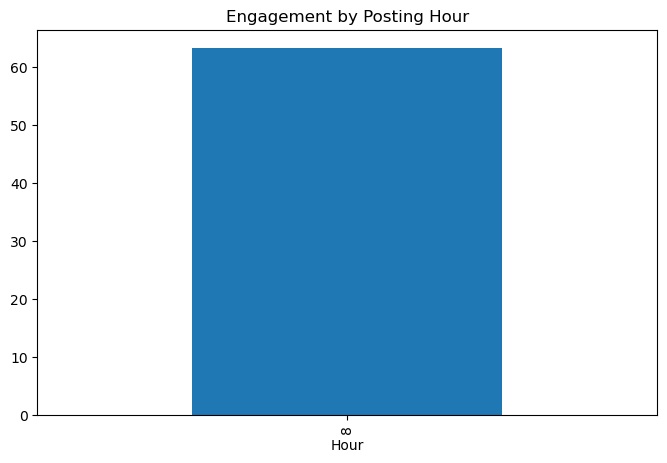

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

hourly.plot(kind='bar')

plt.title("Engagement by Posting Hour")

plt.show()

In [26]:
filter_analysis = engagement.groupby(
    'Insta filter used'
)['Engagement'].mean()

filter_analysis

Insta filter used
no     63.504348
yes    63.147887
Name: Engagement, dtype: float64

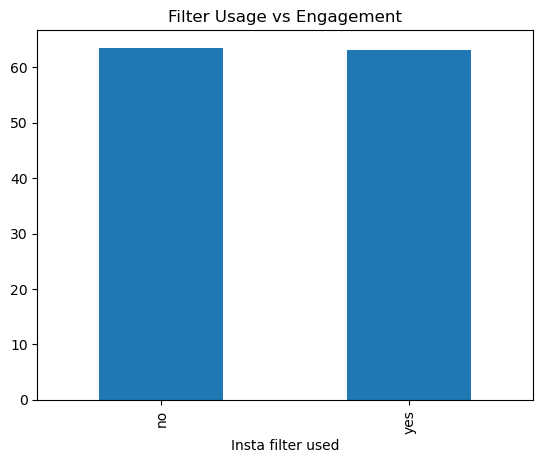

In [27]:
filter_analysis.plot(kind='bar')

plt.title("Filter Usage vs Engagement")

plt.show()

In [28]:
photo_analysis = engagement.groupby(
    'photo type'
)['Engagement'].mean()

photo_analysis

photo type
carousel    62.540000
photo       63.632258
video       63.076923
Name: Engagement, dtype: float64

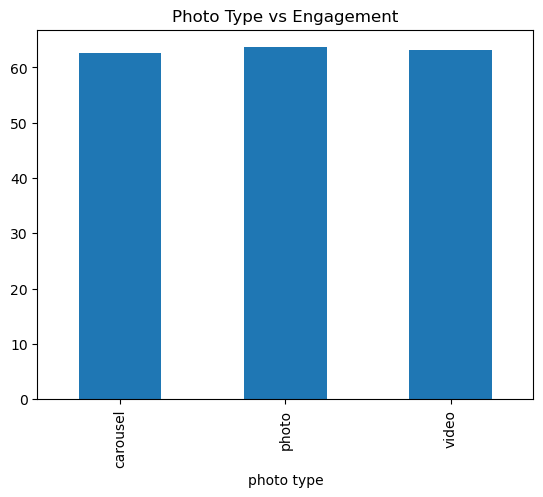

In [29]:
photo_analysis.plot(kind='bar')

plt.title("Photo Type vs Engagement")

plt.show()

In [30]:
user_posts = photos.merge(
    users,
    left_on='user ID',
    right_on='id'
)

user_posts.head()

,id_x,image link,user ID,created dat,Insta filter used,photo type,id_y,name,created time,private/public,post count,Verified status
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo,1,Kenton_Kirlin,16-02-2017 18:22,yes,11,no
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo,1,Kenton_Kirlin,16-02-2017 18:22,yes,11,no
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo,1,Kenton_Kirlin,16-02-2017 18:22,yes,11,no
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo,1,Kenton_Kirlin,16-02-2017 18:22,yes,11,no
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo,1,Kenton_Kirlin,16-02-2017 18:22,yes,11,no


In [31]:
users.groupby(
    'Verified status'
)['post count'].mean()

Verified status
no     218.521739
yes    179.125000
Name: post count, dtype: float64

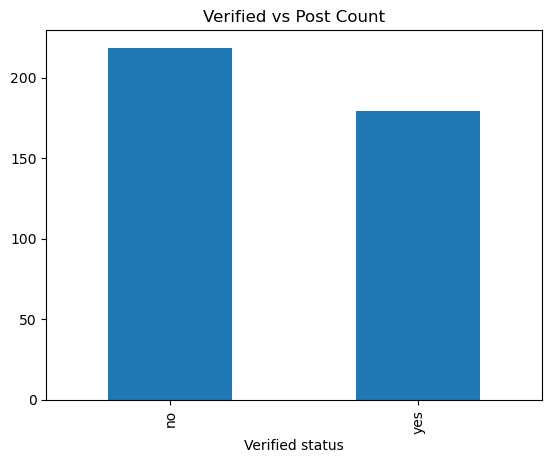

In [32]:
users.groupby(
    'Verified status'
)['post count'].mean().plot(kind='bar')

plt.title("Verified vs Post Count")

plt.show()

In [33]:
tags.head()

,id,tag text,created time,location
0,1,sunset,13-04-2023 08:04,florida
1,2,photography,13-04-2023 08:04,washington DC
2,3,sunrise,13-04-2023 08:04,new york
3,4,landscape,13-04-2023 08:04,london
4,5,food,13-04-2023 08:04,brazil


In [34]:
photo_tags.head()

,photo,tag ID,user id
0,1,13,1
1,1,17,1
2,1,18,2
3,1,19,2
4,1,21,3


In [35]:
hashtag_analysis = photo_tags.merge(
    tags,
    left_on='tag ID',
    right_on='id',
    how='left'
)

hashtag_analysis.head()

,photo,tag ID,user id,id,tag text,created time,location
0,1,13,1,13,fun,13-04-2023 08:04,brazil
1,1,17,1,17,party,13-04-2023 08:04,florida
2,1,18,2,18,concert,13-04-2023 08:04,washington DC
3,1,19,2,19,drunk,13-04-2023 08:04,new york
4,1,21,3,21,smile,13-04-2023 08:04,australia


In [36]:
popular_tags = hashtag_analysis['tag text'].value_counts()

popular_tags.head(10)

tag text
smile      59
beach      42
party      39
fun        38
concert    24
food       24
lol        24
hair       23
happy      22
beauty     20
Name: count, dtype: int64

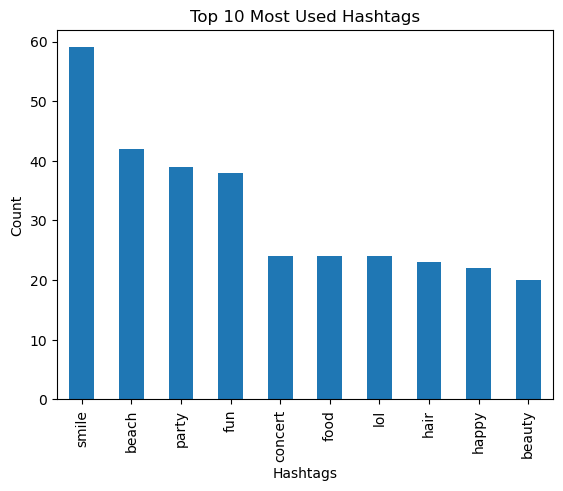

In [37]:
import matplotlib.pyplot as plt

popular_tags.head(10).plot(kind='bar')

plt.title("Top 10 Most Used Hashtags")

plt.xlabel("Hashtags")

plt.ylabel("Count")

plt.show()

In [38]:
users.sort_values(
    by='post count',
    ascending=False
).head(10)

,id,name,created time,private/public,post count,Verified status
22,23,Eveline95,23-01-2017 23:14,no,2400,no
34,35,Lennie_Hartmann40,30-03-2017 03:25,no,2400,no
79,80,Darby_Herzog,06-05-2016 00:14,yes,2400,no
64,65,Adelle96,01-10-2016 00:37,yes,2400,no
21,22,Kenneth64,27-12-2016 09:48,no,1293,no
63,64,Florence99,06-10-2016 23:08,yes,1293,yes
33,34,Pearl7,08-07-2016 21:42,no,1293,no
10,11,Justina.Gaylord27,04-05-2017 16:32,no,1293,no
52,53,Linnea59,07-02-2017 07:49,yes,1293,no
95,96,Keenan.Schamberger60,28-08-2016 14:57,yes,687,no


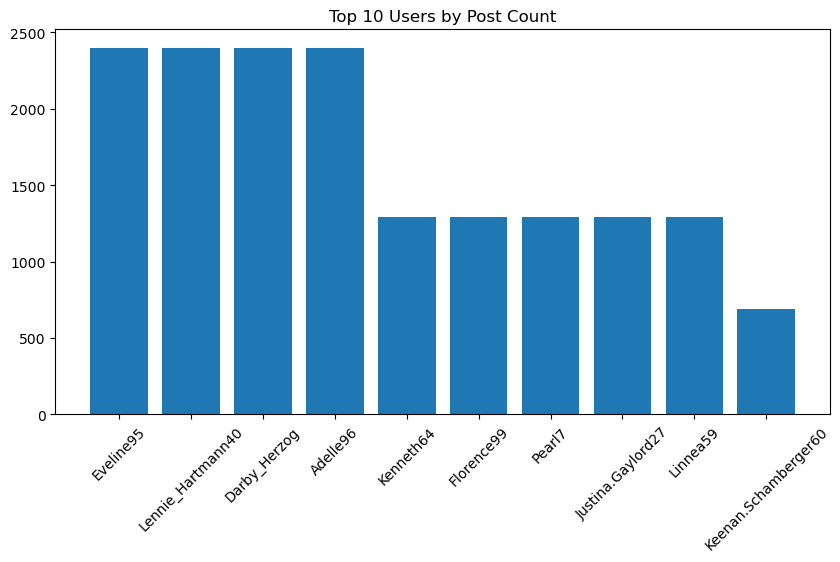

In [39]:
top_users = users.sort_values(
    by='post count',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(top_users['name'], top_users['post count'])

plt.xticks(rotation=45)

plt.title("Top 10 Users by Post Count")

plt.show()

In [41]:
print("Users:", users.shape)
print("Photos:", photos.shape)
print("Likes:", likes.shape)
print("Comments:", comments.shape)
print("Tags:", tags.shape)
print("Photo Tags:", photo_tags.shape)
print("Follows:", follows.shape)

Users: (100, 6)
Photos: (257, 6)
Likes: (8782, 5)
Comments: (7488, 8)
Tags: (21, 4)
Photo Tags: (501, 3)
Follows: (7623, 5)


In [42]:
likes.head()

,user,photo,created time,following or not,like type
0,2,1,13-04-2023 08:04,yes,heart emoji
1,2,4,13-04-2023 08:04,no,thumbs up
2,2,8,13-04-2023 08:04,yes,laughing
3,2,9,13-04-2023 08:04,no,fire
4,2,10,13-04-2023 08:04,yes,clap


In [43]:
comments.head()

,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1
1,2,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2
2,3,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4
3,4,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2
4,5,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1


In [44]:
likes_count = likes.groupby('photo').size().reset_index(name='Likes')

comments_count = comments.groupby('Photo id').size().reset_index(name='Comments')

engagement = photos.merge(
    likes_count,
    left_on='id',
    right_on='photo',
    how='left'
)

engagement = engagement.merge(
    comments_count,
    left_on='id',
    right_on='Photo id',
    how='left'
)

engagement['Likes'] = engagement['Likes'].fillna(0)

engagement['Comments'] = engagement['Comments'].fillna(0)

engagement['Engagement'] = engagement['Likes'] + engagement['Comments']

engagement.head()

,id,image link,user ID,created dat,Insta filter used,photo type,photo,Likes,Photo id,Comments,Engagement
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo,1,25,1,25,50
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo,2,36,2,31,67
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo,3,38,3,27,65
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo,4,38,4,32,70
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo,5,31,5,27,58


In [45]:
top_posts = engagement.sort_values(
    by='Engagement',
    ascending=False
)

top_posts[['id','Engagement']].head(10)

,id,Engagement
12,13,79
144,145,75
146,147,75
117,118,74
226,227,74
195,196,73
224,225,73
126,127,73
122,123,73
152,153,72


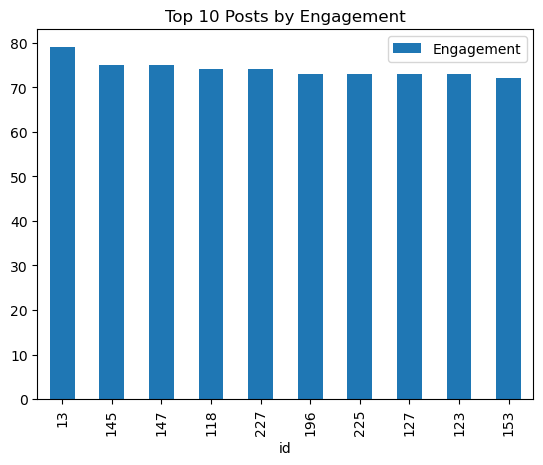

In [46]:
import matplotlib.pyplot as plt

top_posts[['id','Engagement']].head(10).plot(
    x='id',
    y='Engagement',
    kind='bar'
)

plt.title("Top 10 Posts by Engagement")

plt.show()

In [47]:
filter_analysis = engagement.groupby(
    'Insta filter used'
)['Engagement'].mean()

print(filter_analysis)

Insta filter used
no     63.504348
yes    63.147887
Name: Engagement, dtype: float64


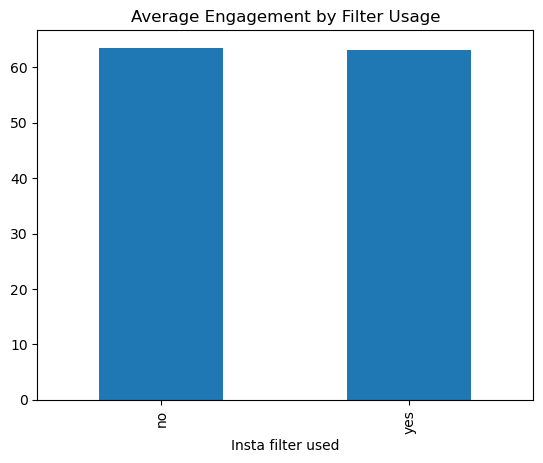

In [48]:
filter_analysis.plot(kind='bar')

plt.title("Average Engagement by Filter Usage")

plt.show()

In [49]:
photo_analysis = engagement.groupby(
    'photo type'
)['Engagement'].mean()

print(photo_analysis)

photo type
carousel    62.540000
photo       63.632258
video       63.076923
Name: Engagement, dtype: float64


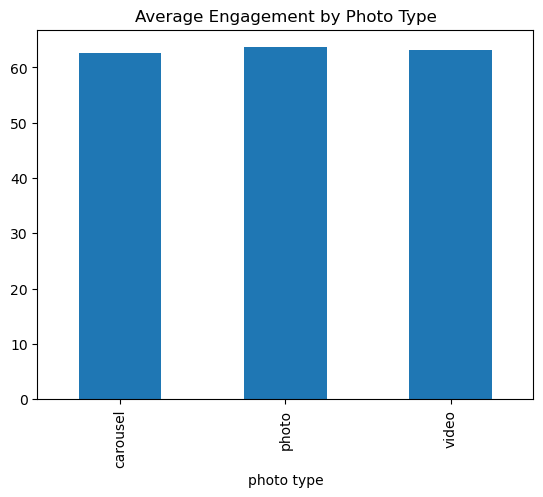

In [50]:
photo_analysis.plot(kind='bar')

plt.title("Average Engagement by Photo Type")

plt.show()

In [51]:
hashtag_analysis = photo_tags.merge(
    tags,
    left_on='tag ID',
    right_on='id'
)

top_tags = hashtag_analysis['tag text'].value_counts()

print(top_tags.head(10))

tag text
smile      59
beach      42
party      39
fun        38
concert    24
food       24
lol        24
hair       23
happy      22
beauty     20
Name: count, dtype: int64


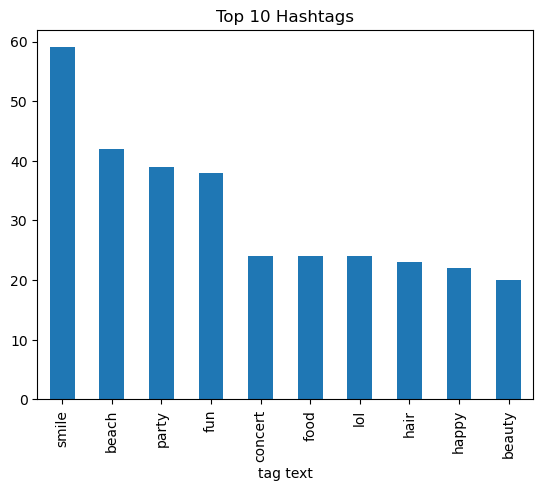

In [52]:
top_tags.head(10).plot(kind='bar')

plt.title("Top 10 Hashtags")

plt.show()

In [53]:
top_users = users.sort_values(
    by='post count',
    ascending=False
)

top_users[['name','post count']].head(10)

,name,post count
22,Eveline95,2400
34,Lennie_Hartmann40,2400
79,Darby_Herzog,2400
64,Adelle96,2400
21,Kenneth64,1293
63,Florence99,1293
33,Pearl7,1293
10,Justina.Gaylord27,1293
52,Linnea59,1293
95,Keenan.Schamberger60,687


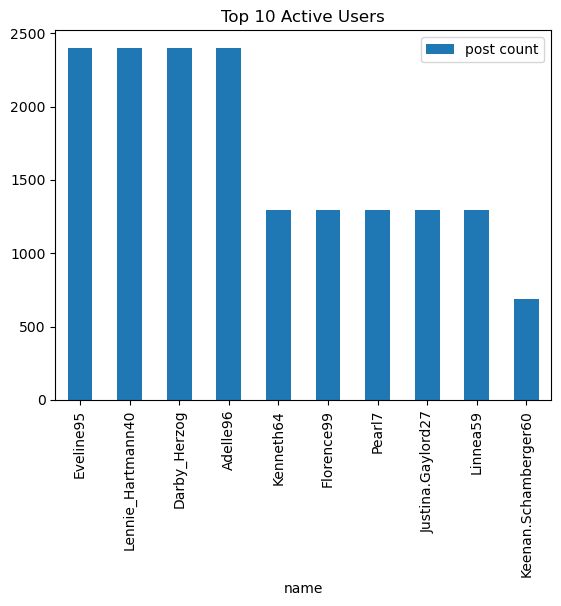

In [54]:
top_users.head(10).plot(
    x='name',
    y='post count',
    kind='bar'
)

plt.title("Top 10 Active Users")

plt.show()